# Module 20: AdaBoost
##Implementing AdaBoost on a Dataset
##Model Evaluation, Limitations & Use Cases

---

### Learning Objectives
By the end of this notebook, you will be able to:
- Implement AdaBoost using scikit-learn
- Understand the role of weak learners
- Interpret key parameters of AdaBoost
- Evaluate model performance properly
- Identify when AdaBoost should and should not be used


## 1. Libraries and Tools
We first import all required libraries. Each library is chosen intentionally.


In [1]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

## 2. Loading the Dataset
We use the Breast Cancer dataset because it is clean, binary, and well-suited for demonstrating boosting behavior.

In [2]:
X, y = load_breast_cancer(return_X_y=True)
print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


## 3. Train-Test Split
We split the dataset so that evaluation is fair and unbiased.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 426
Testing samples: 143


## 4. Baseline Model: Decision Stump
Before boosting, we examine how a single weak learner performs.

In [4]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
y_pred_stump = stump.predict(X_test)
print('Decision Stump Accuracy:', accuracy_score(y_test, y_pred_stump))

Decision Stump Accuracy: 0.8951048951048951


## 5. Building AdaBoost Model
Now we boost the weak learner using AdaBoost.

In [5]:
#Building AdaBoost Model
base_learner = DecisionTreeClassifier(max_depth=1, random_state=42)

ada = AdaBoostClassifier(
    estimator = base_learner,
    n_estimators=20,
    learning_rate=0.3,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.3, n_estimators=20, random_state=42)

**AdaBoostClassifier**

class sklearn.ensemble.AdaBoostClassifier(estimator=None, *, n_estimators=50, learning_rate=1.0, random_state=None)

**Parameters:**
* estimator: object, default=None

The base estimator from which the boosted ensemble is built. Support for sample weighting is required, as well as proper classes_ and n_classes_ attributes. If None, then the base estimator is DecisionTreeClassifier initialized with max_depth=1.

* n_estimatorsint, default=50

The maximum number of estimators at which boosting is terminated. In case of perfect fit, the learning procedure is stopped early. Values must be in the range [1, inf).

* learning_rate: float, default=1.0

Weight applied to each classifier at each boosting iteration. A higher learning rate increases the contribution of each classifier. There is a trade-off between the learning_rate and n_estimators parameters. Values must be in the range (0.0, inf).

* random_state: int, RandomState instance or None, default=None

Controls the random seed given at each estimator at each boosting iteration. Thus, it is only used when estimator exposes a random_state. Pass an int for reproducible output across multiple function calls

## 6. Predictions
AdaBoost makes predictions using a weighted vote of weak learners.

In [6]:
#Predictions
y_pred_ada = ada.predict(X_test)
print('AdaBoost Accuracy: ', accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy:  0.965034965034965


## 7. Detailed Evaluation
Accuracy alone is not enough. We use additional metrics.

In [8]:
print(classification_report(y_test, y_pred_ada))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

Confusion Matrix:
 [[51  3]
 [ 2 87]]


## 8. Effect of Number of Estimators
We now observe how the number of weak learners affects performance.

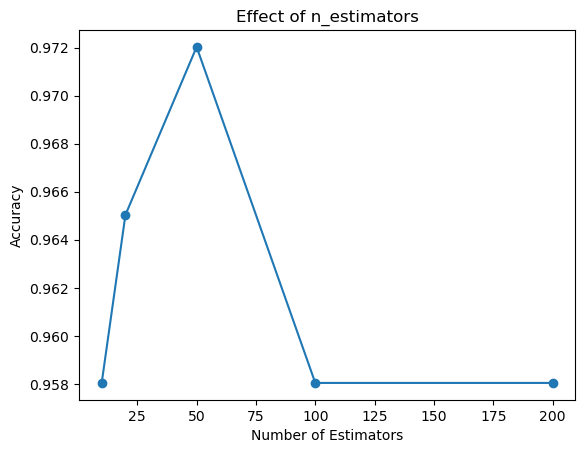

In [10]:
#Effect of Number of Estimators
estimators = [10,20,50,100,200]
accs = []
for n in estimators:
  model = AdaBoostClassifier(
      estimator = base_learner,
      n_estimators = n,
      learning_rate = 0.3,
      random_state = 42
  )
  model.fit(X_train,y_train)
  accs.append(accuracy_score(y_test,model.predict(X_test)))


plt.plot(estimators, accs, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators')
plt.show()